# ==========================================================
# Smart Housing Price Analytics
# Project 3 – Infotact Solutions Internship
# Day 1: Exploratory Data Analysis
# Dataset: King County House Sales Dataset
# Author: Megha Kalachira Ankush
# ==========================================================

In [8]:

from google.colab import files


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('kc_house_data.csv')
print(df.shape)
df.head()

print(df.describe().T)


(21613, 21)
                 count          mean           std           min  \
id             21613.0  4.580302e+09  2.876566e+09  1.000102e+06   
price          21613.0  5.400881e+05  3.671272e+05  7.500000e+04   
bedrooms       21613.0  3.370842e+00  9.300618e-01  0.000000e+00   
bathrooms      21613.0  2.114757e+00  7.701632e-01  0.000000e+00   
sqft_living    21613.0  2.079900e+03  9.184409e+02  2.900000e+02   
sqft_lot       21613.0  1.510697e+04  4.142051e+04  5.200000e+02   
floors         21613.0  1.494309e+00  5.399889e-01  1.000000e+00   
waterfront     21613.0  7.541757e-03  8.651720e-02  0.000000e+00   
view           21613.0  2.343034e-01  7.663176e-01  0.000000e+00   
condition      21613.0  3.409430e+00  6.507430e-01  1.000000e+00   
grade          21613.0  7.656873e+00  1.175459e+00  1.000000e+00   
sqft_above     21613.0  1.788391e+03  8.280910e+02  2.900000e+02   
sqft_basement  21613.0  2.915090e+02  4.425750e+02  0.000000e+00   
yr_built       21613.0  1.971005e+03

In [10]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate ids:", df['id'].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

count    2.143600e+04
mean     5.405293e+05
std      3.676893e+05
min      7.500000e+04
25%      3.221500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64
Houses with 0 bedrooms/bathrooms: 7


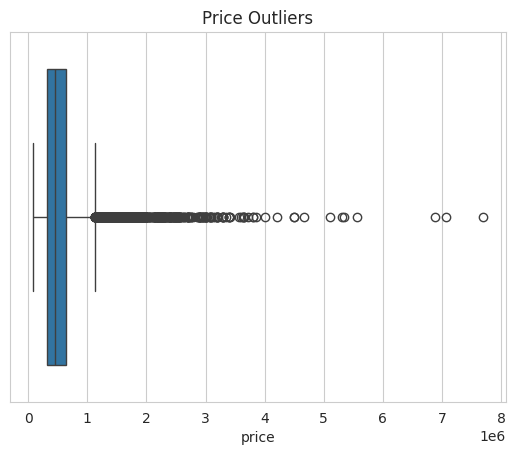

(21435, 21)


<Figure size 640x480 with 0 Axes>

In [11]:
# Basic cleaning
df['date'] = pd.to_datetime(df['date'])
df = df.drop_duplicates(subset='id').reset_index(drop=True)

# Sanity-check outliers
print(df['price'].describe())
print("Houses with 0 bedrooms/bathrooms:", ((df['bedrooms']==0) & (df['bathrooms']==0)).sum())

sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

plt.savefig("price_boxplot.png", dpi=150)

# Remove obvious data errors (e.g. 33-bedroom house is a known typo in this dataset)
df = df[df['bedrooms'] < 15].reset_index(drop=True)
print(df.shape)


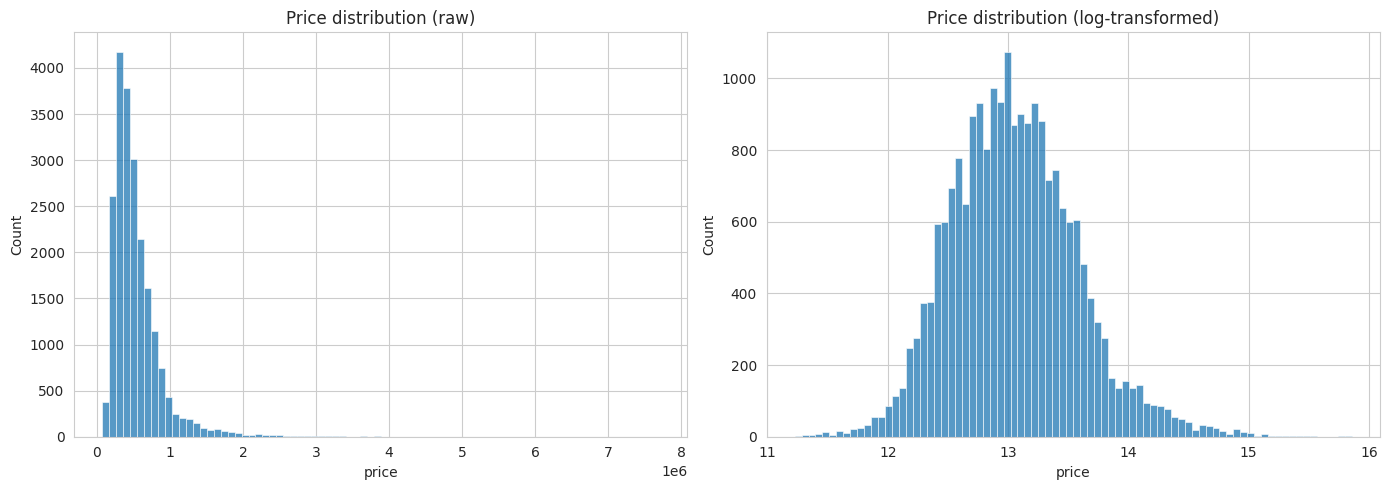

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=80, ax=axes[0])
axes[0].set_title('Price distribution (raw)')
sns.histplot(np.log1p(df['price']), bins=80, ax=axes[1])
axes[1].set_title('Price distribution (log-transformed)')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150)
plt.show()


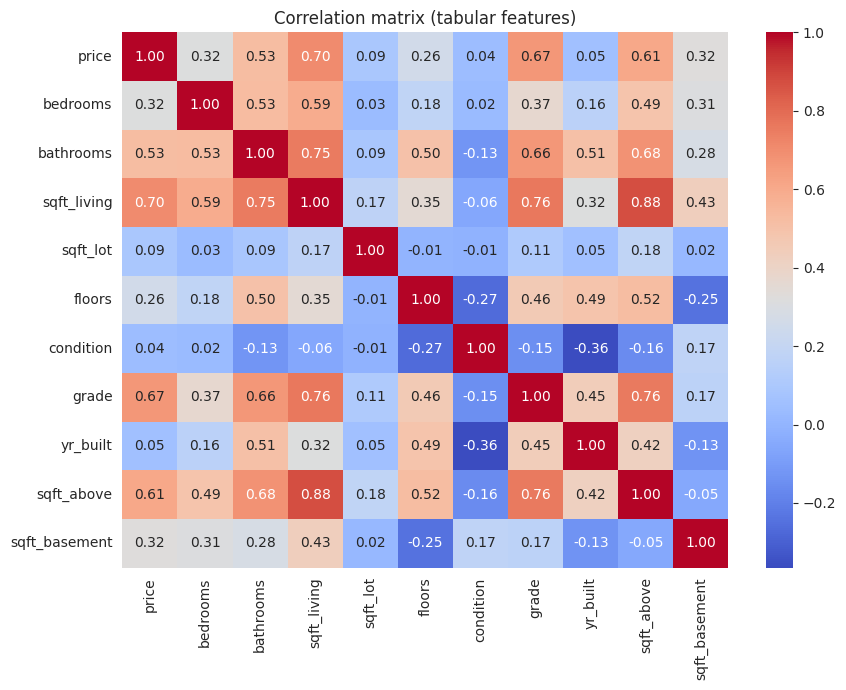

In [13]:
corr = df[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors',
           'condition','grade','yr_built','sqft_above','sqft_basement']].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix (tabular features)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


In [14]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[47.55, -122.2], zoom_start=9, tiles='cartodbpositron')
sample = df.sample(2000, random_state=42)
HeatMap(data=sample[['lat','long','price']].values.tolist(), radius=8).add_to(m)
m.save('price_heatmap.html')
m


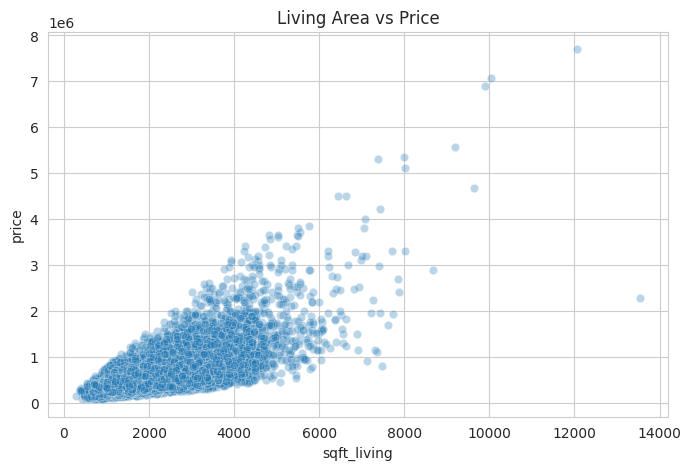

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.3)
plt.title("Living Area vs Price")
plt.savefig("living_vs_price.png")
plt.show()

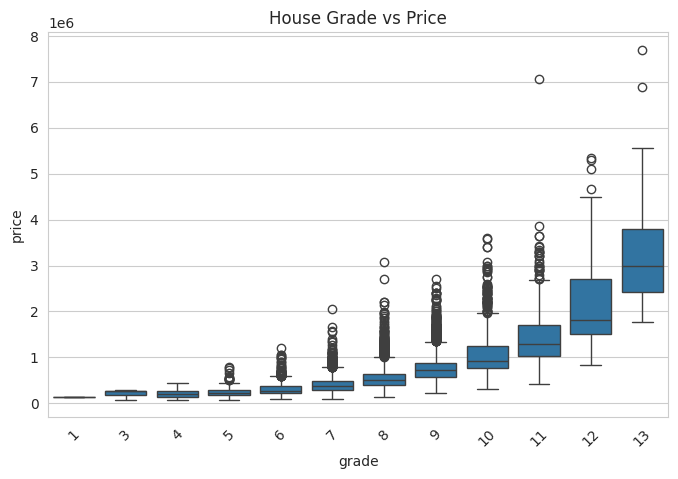

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='grade', y='price', data=df)
plt.xticks(rotation=45)
plt.title("House Grade vs Price")
plt.savefig("grade_vs_price.png")
plt.show()

In [17]:
df.to_csv("cleaned_kc_house_data.csv", index=False)

## Day 1 Summary

- Loaded and explored the King County Housing dataset.
- Verified data integrity and removed duplicate property records.
- Corrected obvious data anomalies (e.g., unrealistic bedroom counts).
- Examined feature distributions and confirmed price skewness.
- Identified strong correlations between price, living area, and house grade.
- Visualized the spatial distribution of property prices using an interactive heatmap.
- Exported cleaned dataset for feature engineering in Day 2.